# Logistic Regression
**Reference**: [GeeksForGeeks — Understanding Logistic Regression](https://www.geeksforgeeks.org/machine-learning/understanding-logistic-regression/)

---

## 1. What is Logistic Regression?

**Logistic Regression** is a **supervised machine learning algorithm** used for **classification problems**.  
It predicts the **probability** that an input belongs to a particular class.

- Input  → continuous / categorical features
- Output → **probability between 0 and 1** (then thresholded to a class label)

> Despite the word *"Regression"* in the name, it is a **classification** algorithm.  
> The regression part refers to the linear equation it builds internally.

### Linear Regression vs Logistic Regression

| | Linear Regression | Logistic Regression |
|-|-------------------|--------------------|
| **Output** | Continuous number (e.g. price) | Probability → class label |
| **Output range** | −∞ to +∞ | 0 to 1 |
| **Used for** | Regression | Classification |
| **Error function** | Mean Squared Error | Log Loss (Cross-Entropy) |
| **Estimation method** | Least Squares | Maximum Likelihood |

---
## 2. Types of Logistic Regression

| Type | Classes | Example | Function used |
|------|---------|---------|---------------|
| **Binomial (Binary)** | 2 (Yes/No, 0/1) | Spam vs Ham ← our example | Sigmoid |
| **Multinomial** | 3 or more (unordered) | Cat vs Dog vs Bird | Softmax |
| **Ordinal** | 3 or more (ordered) | Low / Medium / High rating | Ordered logit |

---
## 3. The Sigmoid Function

The **sigmoid function** (also called the logistic function) converts any real number into a value between **0 and 1**:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

Where:
- $z = w \cdot X + b$ — the **linear combination** of weights and features (same as linear regression)
- $e$ — Euler's number (~2.718)

| z value | σ(z) | Meaning |
|---------|------|---------|
| Very large positive | ≈ 1.0 | Almost certainly class 1 |
| 0 | 0.5 | Exactly on the decision boundary |
| Very large negative | ≈ 0.0 | Almost certainly class 0 |

**Decision rule**: if σ(z) ≥ 0.5 → predict class 1, else predict class 0

In [1]:
# ── Imports ───────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported!")

Libraries imported!


https://www.geeksforgeeks.org/machine-learning/understanding-logistic-regression/

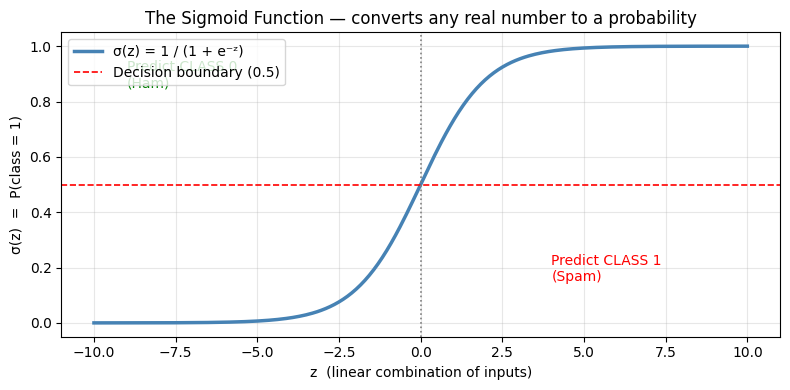

In [2]:
# ── Visualise the Sigmoid Function ───────────────────────────────────────────

def sigmoid(z):
    # The core formula: 1 / (1 + e^(-z))
    # np.exp(-z) computes e^(-z) element-wise for the entire array at once
    return 1 / (1 + np.exp(-z))

z = np.linspace(-10, 10, 300)   # 300 evenly spaced values from -10 to +10
sigma = sigmoid(z)

plt.figure(figsize=(8, 4))
plt.plot(z, sigma, color='steelblue', linewidth=2.5, label='σ(z) = 1 / (1 + e⁻ᶻ)')

# Decision boundary at z=0, σ=0.5
plt.axhline(0.5, color='red', linestyle='--', linewidth=1.2, label='Decision boundary (0.5)')
plt.axvline(0.0, color='gray', linestyle=':', linewidth=1.2)

# Annotate the three regions
plt.text(-9, 0.85, 'Predict CLASS 0\n(Ham)', fontsize=10, color='green')
plt.text( 4, 0.15, 'Predict CLASS 1\n(Spam)', fontsize=10, color='red')

plt.xlabel('z  (linear combination of inputs)')
plt.ylabel('σ(z)  =  P(class = 1)')
plt.title('The Sigmoid Function — converts any real number to a probability')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

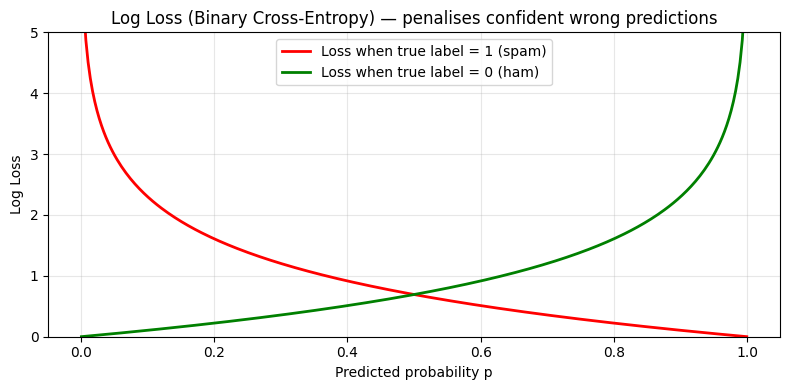

Key insight:
  If true=SPAM (1) but model says p=0.01  → loss = 4.61 (huge penalty!)
  If true=SPAM (1) but model says p=0.99  → loss = 0.0101 (tiny penalty)


In [3]:
# ── Visualise Log Loss ────────────────────────────────────────────────────────
# Shows WHY we use log loss: it punishes confident wrong predictions HARD.

p = np.linspace(0.001, 0.999, 300)   # predicted probability values

# Log loss when true label y=1: -log(p)
# When p is close to 0 but y=1, this loss shoots to infinity → model is heavily penalised
loss_y1 = -np.log(p)

# Log loss when true label y=0: -log(1-p)
# When p is close to 1 but y=0, this loss shoots to infinity
loss_y0 = -np.log(1 - p)

plt.figure(figsize=(8, 4))
plt.plot(p, loss_y1, color='red',   linewidth=2, label='Loss when true label = 1 (spam)')
plt.plot(p, loss_y0, color='green', linewidth=2, label='Loss when true label = 0 (ham)')
plt.xlabel('Predicted probability p')
plt.ylabel('Log Loss')
plt.title('Log Loss (Binary Cross-Entropy) — penalises confident wrong predictions')
plt.ylim(0, 5)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Key insight:")
print("  If true=SPAM (1) but model says p=0.01  → loss =", round(-np.log(0.01), 2), "(huge penalty!)")
print("  If true=SPAM (1) but model says p=0.99  → loss =", round(-np.log(0.99), 4), "(tiny penalty)")

---
## 5. Assumptions of Logistic Regression

*(From GeeksForGeeks)*

| # | Assumption | What it means |
|---|-----------|---------------|
| 1 | **Independent observations** | Each row in the dataset is independent — no correlation between samples |
| 2 | **Binary (or multiclass) dependent variable** | Output must be categorical, not continuous |
| 3 | **Linear relationship with log-odds** | Features should have a linear relationship with log(p / 1-p) |
| 4 | **No extreme outliers** | Outliers can distort the decision boundary |
| 5 | **Large enough sample size** | Rule of thumb: at least 10 samples per feature |
| 6 | **Little or no multicollinearity** | Features should not be highly correlated with each other |

---
## 6. Advantages and Disadvantages

### Advantages
| ✅ Advantage | Explanation |
|-------------|-------------|
| Simple and fast | Linear under the hood; trains in seconds even on large datasets |
| Probabilistic output | Returns P(spam) not just spam/ham — you can set custom thresholds |
| Interpretable | Each weight tells you how much a feature contributes to the prediction |
| Works well for text | Sparse high-dimensional TF-IDF vectors are handled natively |
| Less prone to overfitting | Regularisation (C parameter) controls model complexity |
| Scales to large data | Online learning variants (SGD) exist for streaming data |

### Disadvantages
| ❌ Disadvantage | Explanation |
|----------------|-------------|
| Assumes linear boundary | Cannot learn curved or complex decision surfaces |
| Feature engineering required | Non-linear relationships must be manually encoded |
| Sensitive to outliers | Extreme values skew weight updates |
| Needs feature scaling | For non-text numeric data, features on different scales hurt convergence |
| Not great for multicollinear features | Correlated features create unstable, unreliable weights |

---
## 7. Example 1 — Binomial Logistic Regression (Breast Cancer Dataset)

*(GeeksForGeeks style — sklearn built-in dataset)*

**Task**: Predict whether a tumour is **Malignant (1)** or **Benign (0)** based on 30 numeric features.

In [4]:
# ── Binomial Logistic Regression: Breast Cancer ───────────────────────────────

from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

# load_breast_cancer() is a classic sklearn toy dataset
# 569 samples, 30 numeric features (tumour measurements), 2 classes
cancer = load_breast_cancer()
X_cancer = cancer.data    # feature matrix: 569 × 30
y_cancer = cancer.target  # labels: 0=malignant, 1=benign

print(f"Dataset shape : {X_cancer.shape}")
print(f"Classes       : {cancer.target_names}")
print(f"Class counts  : {np.bincount(y_cancer)}")

# Train/test split
X_tr, X_te, y_tr, y_te = train_test_split(
    X_cancer, y_cancer, test_size=0.2, random_state=42
)

# StandardScaler: REQUIRED for numeric data.
# Rescales each feature to mean=0, std=1.
# WHY: Features have very different ranges (e.g. area ~1000 vs smoothness ~0.1).
#      Without scaling, large-valued features dominate gradient steps.
scaler = StandardScaler()
X_tr_scaled = scaler.fit_transform(X_tr)   # fit on train, transform train
X_te_scaled = scaler.transform(X_te)       # only transform test — NEVER fit on test

# Train Logistic Regression
lr_cancer = LogisticRegression(max_iter=1000, random_state=42)
lr_cancer.fit(X_tr_scaled, y_tr)

y_pred_cancer = lr_cancer.predict(X_te_scaled)

print(f"\nAccuracy : {accuracy_score(y_te, y_pred_cancer)*100:.2f}%")
print("\n", classification_report(y_te, y_pred_cancer, target_names=cancer.target_names))

Dataset shape : (569, 30)
Classes       : ['malignant' 'benign']
Class counts  : [212 357]

Accuracy : 97.37%

               precision    recall  f1-score   support

   malignant       0.98      0.95      0.96        43
      benign       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



---
## 8. Example 2 — Multinomial Logistic Regression (Digits Dataset)

*(GeeksForGeeks style)*

**Task**: Classify handwritten digits **0–9** (10 classes) from 8×8 pixel images.  
This is a **multi-class** problem — Logistic Regression uses the **Softmax** function internally.

In [ ]:
# ── Multinomial Logistic Regression: Digits ───────────────────────────────────

from sklearn.datasets import load_digits

# 1797 samples, 64 features (8×8 pixel values), 10 classes (digits 0-9)
digits = load_digits()
X_digits = digits.data    # 1797 × 64
y_digits = digits.target  # 0 to 9

print(f"Dataset shape : {X_digits.shape}")
print(f"Classes       : {digits.target_names}")

# Show a few sample digits
fig, axes = plt.subplots(1, 10, figsize=(12, 2))
for ax, idx in zip(axes, range(10)):
    # Find the first occurrence of each digit class
    sample_idx = np.where(y_digits == idx)[0][0]
    ax.imshow(digits.images[sample_idx], cmap='gray_r')
    ax.set_title(str(idx), fontsize=12)
    ax.axis('off')
plt.suptitle('Sample digits from the dataset', y=1.05)
plt.tight_layout()
plt.show()

# Split and scale
X_tr_d, X_te_d, y_tr_d, y_te_d = train_test_split(
    X_digits, y_digits, test_size=0.2, random_state=42
)
scaler_d = StandardScaler()
X_tr_d = scaler_d.fit_transform(X_tr_d)
X_te_d = scaler_d.transform(X_te_d)

# multi_class='multinomial' → uses Softmax (one probability per class, all sum to 1)
# solver='lbfgs'            → supports multinomial loss natively
lr_digits = LogisticRegression(
    multi_class='multinomial', solver='lbfgs', max_iter=1000, random_state=42
)
lr_digits.fit(X_tr_d, y_tr_d)

y_pred_d = lr_digits.predict(X_te_d)
print(f"\nMultinomial LR Accuracy : {accuracy_score(y_te_d, y_pred_d)*100:.2f}%")
print("\n", classification_report(y_te_d, y_pred_d))

---
## 9. Example 3 — Spam/Ham SMS Classification (Text Data)

**Task**: Classify SMS messages as `spam` or `ham` using TF-IDF features.  
This is our main hands-on example using real-world text data.

In [5]:
# ── Spam/Ham Dataset ──────────────────────────────────────────────────────────
# Source: https://archive.ics.uci.edu/ml/datasets/SMS+Spam+Collection
# In a real project: df = pd.read_csv("spam.csv", encoding='latin-1')

data = {
    'label': ['ham','ham','spam','ham','spam',
              'spam','ham','ham','spam','ham',
              'ham','spam','ham','spam','ham',
              'spam','ham','ham','spam','ham'],
    'message': [
        "Go until jurong point, crazy.. Available only in bugis n great world la e buffet",
        "Ok lar... Joking wif u oni...",
        "Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005.",
        "U dun say so early hor... U c already then say...",
        "WINNER!! As a valued network customer you have been selected to receive a prize.",
        "Congratulations! You've won a £1000 Walmart gift card. Click here to claim now!",
        "As per your request 'Melle Melle (Oru Minnaminunginte Nurungu Vettam)'",
        "Even my brother is not like to speak with me. They treat me like aids patent.",
        "SIX chances to win CASH! From 100 to 20,000 pounds txt> CSH11 and send to 87575.",
        "I'm gonna be home soon and i don't want to talk about this stuff anymore tonight",
        "I've been searching for the right words to thank you for this breather.",
        "URGENT! You have won a 1 week FREE membership in our £100,000 Prize Jackpot!",
        "I HAVE A DATE ON SUNDAY WITH WILL!!",
        "XXXMobileMovieClub: To use your credit, click the WAP link in the next txt msg.",
        "Oh k...i'm watching here:)",
        "England v Macedonia - dont miss the goals/team news. Txt ur national team.",
        "Is that seriously how you spell his name?",
        "I'm going to try for 2 months ha ha only joking",
        "Call from landline or mobile to claim your FREE prize! Text WIN to 80082.",
        "So ü pay first lar... Then when is da stock comin...",
    ]
}

df = pd.DataFrame(data)

# Convert text label to integer: spam=1, ham=0
# Machines work with numbers — this mapping is mandatory before any ML step.
df['label_num'] = df['label'].map({'spam': 1, 'ham': 0})

print(f"Dataset shape: {df.shape}")
print(f"\nClass distribution:\n{df['label'].value_counts()}")
df.head()

Dataset shape: (20, 3)

Class distribution:
ham     12
spam     8
Name: label, dtype: int64


,label,message,label_num
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,spam,WINNER!! As a valued network customer you have...,1


In [6]:
# ── TF-IDF Feature Extraction ─────────────────────────────────────────────────
#
# WHY TF-IDF?
#   ML models need numbers, not words.
#   TF-IDF assigns a score to each word based on:
#     TF  = how often the word appears in THIS message (term frequency)
#     IDF = inverse of how often it appears across ALL messages
#           → common words like "the", "is" get LOW scores
#           → rare informative words like "FREE", "WIN" get HIGH scores

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

# stop_words='english' → auto-removes English filler words
# lowercase=True (default) → case-insensitive
vectorizer = TfidfVectorizer(stop_words='english', lowercase=True)

X = vectorizer.fit_transform(df['message'])   # sparse matrix: rows=messages, cols=words
y = df['label_num']                           # target: 0=ham, 1=spam

print(f"Feature matrix: {X.shape[0]} messages × {X.shape[1]} unique words")

# stratify=y → ensures both train and test sets have the same spam/ham ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
print(f"Train: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples")

Feature matrix: 20 messages × 118 unique words
Train: 15 samples | Test: 5 samples


In [7]:
# ── Train Logistic Regression ─────────────────────────────────────────────────

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

# C = 1/λ — inverse regularisation strength
#   Low C  = strong regularisation = simpler model = less overfitting
#   High C = weak regularisation   = fits training data closely
# solver='lbfgs' → Limited-memory Broyden–Fletcher–Goldfarb–Shanno optimiser
#                  efficient for small-to-medium datasets
# max_iter=1000  → allow enough iterations for convergence on text data
lr_model = LogisticRegression(C=1.0, solver='lbfgs', max_iter=1000, random_state=42)

# .fit() runs gradient descent to minimise Log Loss
# It learns one weight per word in the vocabulary
lr_model.fit(X_train, y_train)

# .predict()       → hard class labels (0 or 1)
# .predict_proba() → probability array [[P(ham), P(spam)], ...]
lr_preds = lr_model.predict(X_test)
lr_probs = lr_model.predict_proba(X_test)

print("=== Spam/Ham Logistic Regression Results ===\n")
print(f"Accuracy : {accuracy_score(y_test, lr_preds)*100:.1f}%\n")
print(classification_report(y_test, lr_preds, target_names=['ham','spam']))

=== Spam/Ham Logistic Regression Results ===

Accuracy : 60.0%

              precision    recall  f1-score   support

         ham       0.60      1.00      0.75         3
        spam       0.00      0.00      0.00         2

    accuracy                           0.60         5
   macro avg       0.30      0.50      0.37         5
weighted avg       0.36      0.60      0.45         5



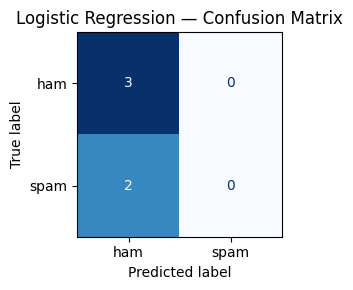

In [8]:
# ── Confusion Matrix ──────────────────────────────────────────────────────────
#
#               Predicted HAM      Predicted SPAM
#  Actual HAM  |  TN (correct)   |  FP (false alarm — ham flagged as spam) |
#  Actual SPAM |  FN (missed spam)|  TP (correctly caught spam)             |
#
# For spam filtering, FN (missing spam) is worse than FP (false alarm).

fig, ax = plt.subplots(figsize=(4, 3))
cm = confusion_matrix(y_test, lr_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['ham', 'spam'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title("Logistic Regression — Confusion Matrix")
plt.tight_layout()
plt.show()

---
## 10. Evaluation Metrics

*(GeeksForGeeks)*

| Metric | Formula | What it measures |
|--------|---------|------------------|
| **Accuracy** | (TP+TN) / Total | Overall correct predictions |
| **Precision** | TP / (TP+FP) | Of predicted spam, how many were actually spam? |
| **Recall** | TP / (TP+FN) | Of all actual spam, how many did we catch? |
| **F1-Score** | 2 × (P×R)/(P+R) | Harmonic mean of Precision and Recall |
| **AUC-ROC** | Area under ROC curve | Overall discrimination ability (0.5=random, 1.0=perfect) |

> **Which metric to use for spam?**  
> Recall is more important — missing a spam (FN) is worse than a false alarm (FP).

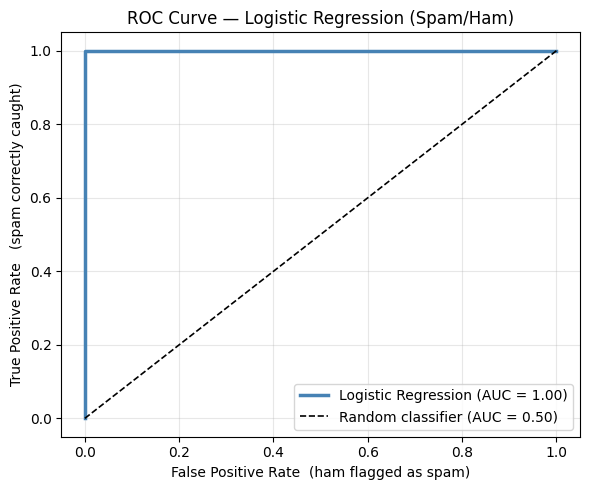

AUC-ROC Score : 1.0000


In [9]:
# ── ROC Curve and AUC ─────────────────────────────────────────────────────────
#
# ROC = Receiver Operating Characteristic
# Plots: True Positive Rate (Recall) vs False Positive Rate at different thresholds.
# AUC  = Area Under the ROC Curve.
#   AUC = 1.0 → perfect model
#   AUC = 0.5 → random guessing
#   AUC = 0.0 → perfectly wrong (flip predictions!)

from sklearn.metrics import roc_curve, roc_auc_score

# lr_probs[:, 1] = P(spam) for each test message
fpr, tpr, thresholds = roc_curve(y_test, lr_probs[:, 1])
auc = roc_auc_score(y_test, lr_probs[:, 1])

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='steelblue', linewidth=2.5,
         label=f'Logistic Regression (AUC = {auc:.2f})')

# Diagonal line = random classifier (AUC = 0.5)
plt.plot([0, 1], [0, 1], 'k--', linewidth=1.2, label='Random classifier (AUC = 0.50)')

plt.xlabel('False Positive Rate  (ham flagged as spam)')
plt.ylabel('True Positive Rate   (spam correctly caught)')
plt.title('ROC Curve — Logistic Regression (Spam/Ham)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print(f"AUC-ROC Score : {auc:.4f}")

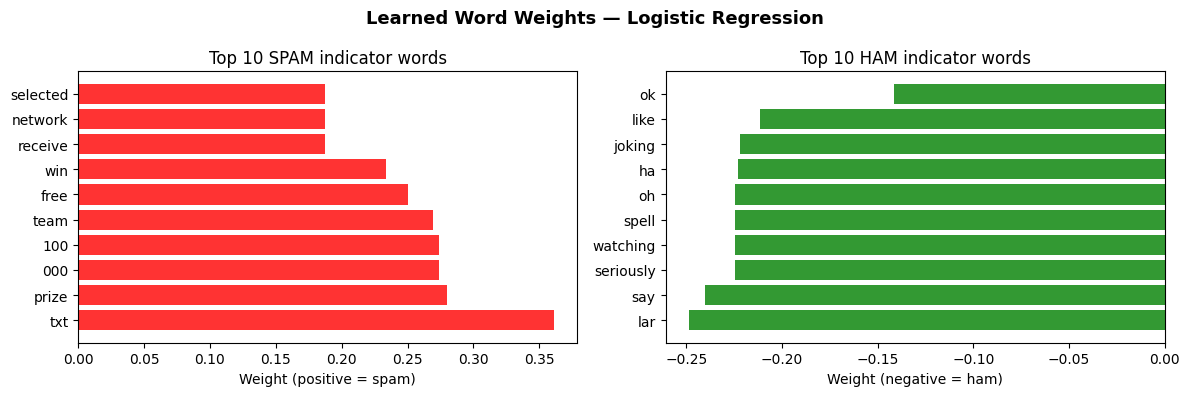

In [10]:
# ── Interpretability — Word Weights ──────────────────────────────────────────
#
# Logistic Regression is interpretable because every feature (word) has a weight.
# Positive weight → word pushes prediction toward SPAM
# Negative weight → word pushes prediction toward HAM
# Magnitude       → how strong the push is

feature_names = vectorizer.get_feature_names_out()  # vocabulary
coefficients  = lr_model.coef_[0]                   # learned weight per word

coef_df = pd.DataFrame({'word': feature_names, 'weight': coefficients})
coef_df = coef_df.sort_values('weight', ascending=False)

# Plot top 10 spam words and top 10 ham words
top_spam = coef_df.head(10)
top_ham  = coef_df.tail(10).sort_values('weight')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].barh(top_spam['word'], top_spam['weight'], color='red', alpha=0.8)
axes[0].set_title('Top 10 SPAM indicator words')
axes[0].set_xlabel('Weight (positive = spam)')

axes[1].barh(top_ham['word'], top_ham['weight'], color='green', alpha=0.8)
axes[1].set_title('Top 10 HAM indicator words')
axes[1].set_xlabel('Weight (negative = ham)')

plt.suptitle('Learned Word Weights — Logistic Regression', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [11]:
# ── Predict Custom Messages ───────────────────────────────────────────────────

new_messages = [
    "Congratulations! You've won a FREE iPhone. Click to claim now!",
    "Hey, are you coming to dinner tonight?",
    "URGENT: Your bank account has been compromised. Call us immediately!",
    "Can we reschedule our meeting to 3pm?",
    "WIN a holiday! Text WIN to 88888 now. Free entry."
]

# transform() — NOT fit_transform().
# We must reuse the vocabulary learned during training.
# If we fit again, the word→column mapping changes and predictions are meaningless.
new_X     = vectorizer.transform(new_messages)
new_preds = lr_model.predict(new_X)
new_probs = lr_model.predict_proba(new_X)

print("Custom Message Predictions:\n")
print(f"{'Message':<62} {'Label':<6} {'Spam Prob'}")
print("-" * 80)
for msg, pred, prob in zip(new_messages, new_preds, new_probs):
    label = 'SPAM' if pred == 1 else 'HAM'
    print(f"{msg[:60]:<62} {label:<6} {prob[1]*100:.1f}%")

Custom Message Predictions:

Message                                                        Label  Spam Prob
--------------------------------------------------------------------------------
Congratulations! You've won a FREE iPhone. Click to claim no   HAM    44.2%
Hey, are you coming to dinner tonight?                         HAM    36.5%
URGENT: Your bank account has been compromised. Call us imme   HAM    43.0%
Can we reschedule our meeting to 3pm?                          HAM    39.0%
WIN a holiday! Text WIN to 88888 now. Free entry.              HAM    46.7%


---
## 11. Summary

| Concept | Key Point |
|---------|----------|
| **Algorithm** | Supervised classification using sigmoid function |
| **Output** | Probability between 0 and 1 |
| **Decision rule** | P ≥ 0.5 → class 1, P < 0.5 → class 0 |
| **Cost function** | Log Loss (Binary Cross-Entropy) |
| **Training** | Gradient descent minimises the cost |
| **Types** | Binomial / Multinomial / Ordinal |
| **Text data** | Pair with TF-IDF; no scaling needed |
| **Numeric data** | Always apply `StandardScaler` first |
| **Key parameter** | `C` — inverse regularisation strength |
| **Interpretability** | High — weights directly show feature importance |

### Steps to use Logistic Regression (GFG style)
1. Collect and clean data
2. Encode labels as numbers (0/1)
3. Extract features (TF-IDF for text / StandardScaler for numeric)
4. Split into train/test sets
5. Create `LogisticRegression()` model
6. Train with `.fit(X_train, y_train)`
7. Predict with `.predict(X_test)`
8. Evaluate: accuracy, precision, recall, F1, AUC-ROC

---
**Reference**: [GeeksForGeeks — Understanding Logistic Regression](https://www.geeksforgeeks.org/machine-learning/understanding-logistic-regression/)